Opening raw data file C:\Users\Hangeulkim\mne_data\MNE-sample-data\MEG\sample\sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
<Info | 21 non-empty values
 acq_pars: ACQch001 110113 ACQch002 110112 ACQch003 110111 ACQch004 110122 ...
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 description: acquisition (megacq) VectorView system at NMR-MGH
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 events: 1 item (list)
 experimenter: MEG
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 172.2 Hz
 meas

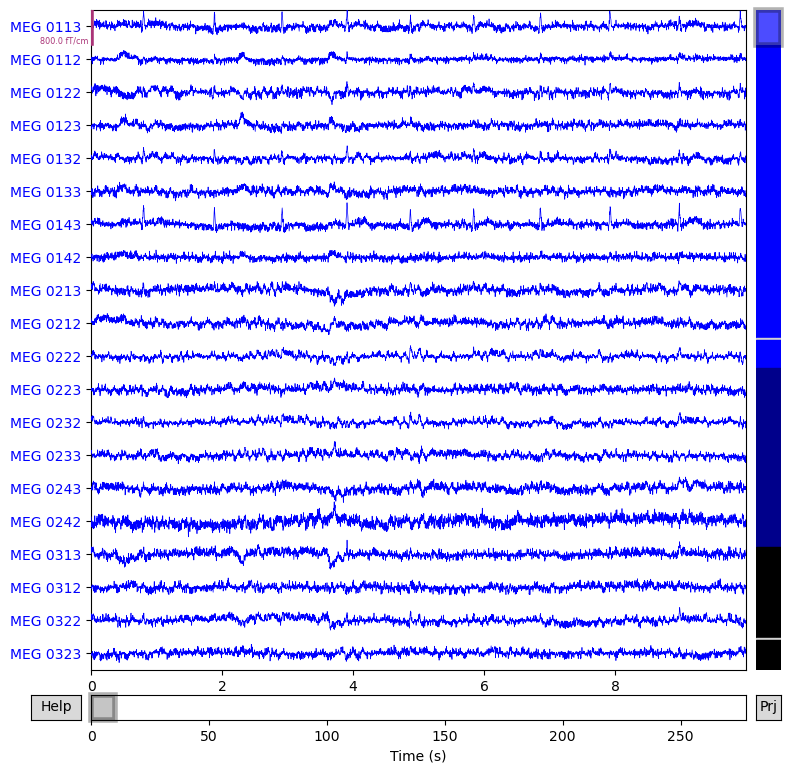

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1983 samples (3.302 s)



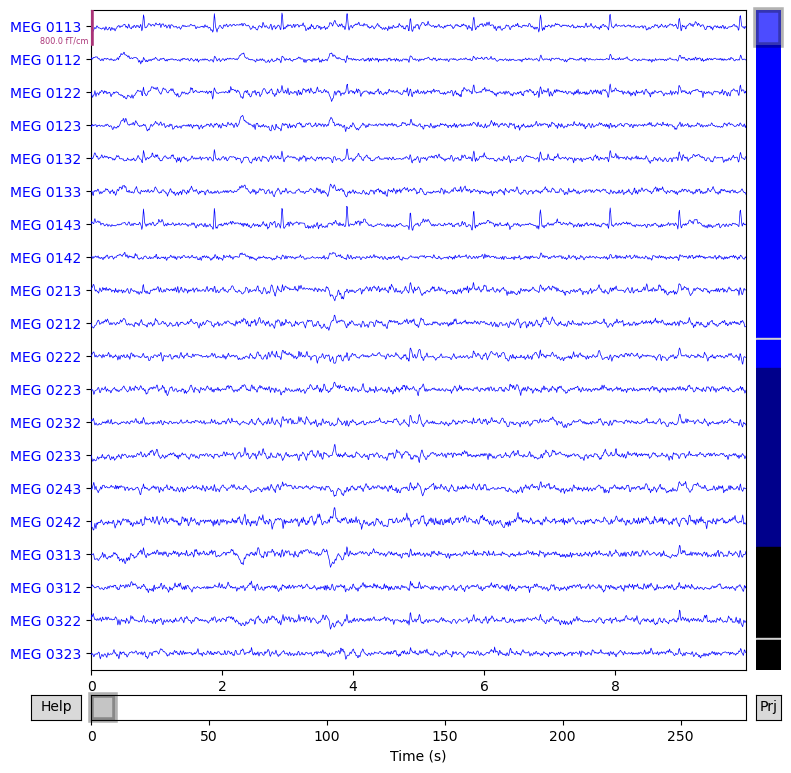

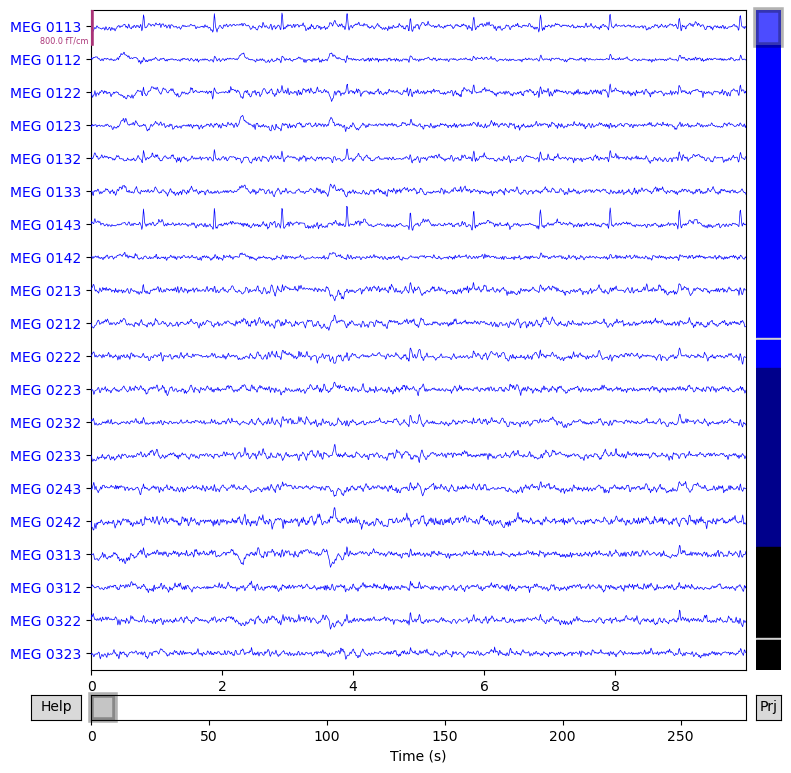

In [1]:
import mne

sample_path = mne.datasets.sample.data_path()
raw_fname = sample_path / 'MEG' / 'sample' / 'sample_audvis_raw.fif'
raw = mne.io.read_raw_fif(raw_fname, preload=True)
print(raw.info)

# TODO: 처음 10초 / 20채널만 시각화
raw.plot(duration=10, n_channels=20)

# TODO: 1~40Hz 대역통과 필터 적용
# 힌트: raw.filter(l_freq, h_freq)
raw.filter(1. ,40. )

# TODO: 필터 후 다시 plot
raw.plot(duration=10, n_channels=20)

600.614990234375 59
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


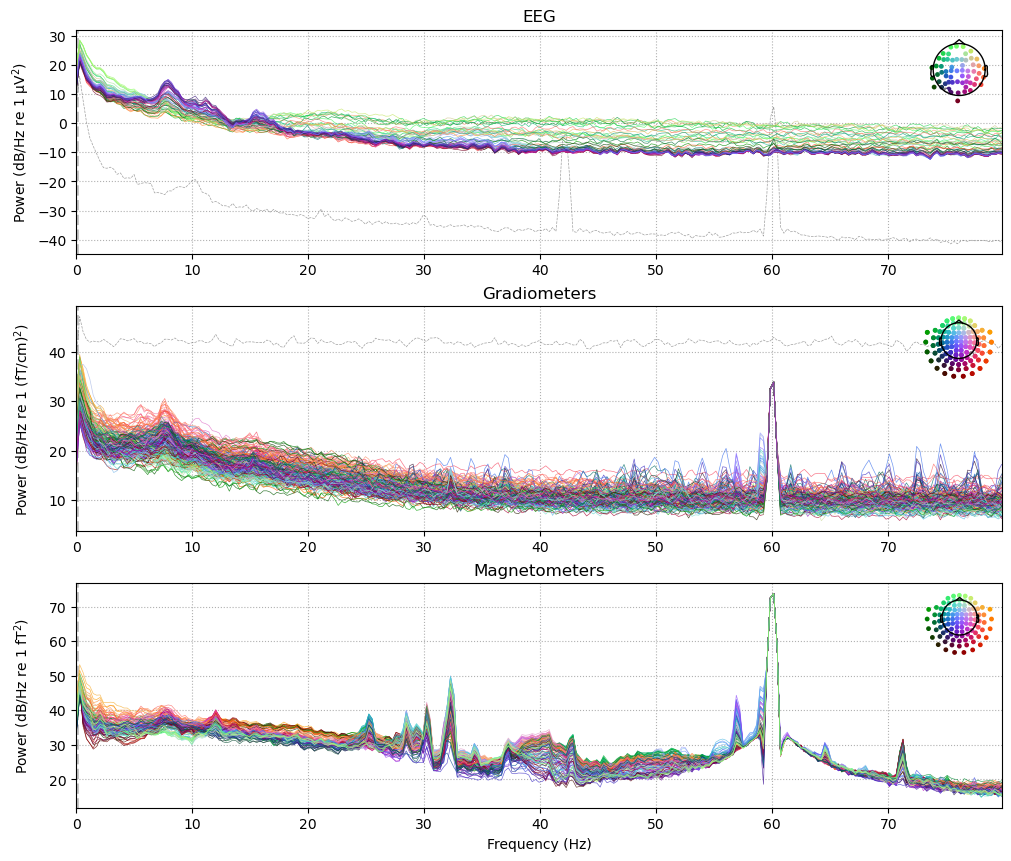

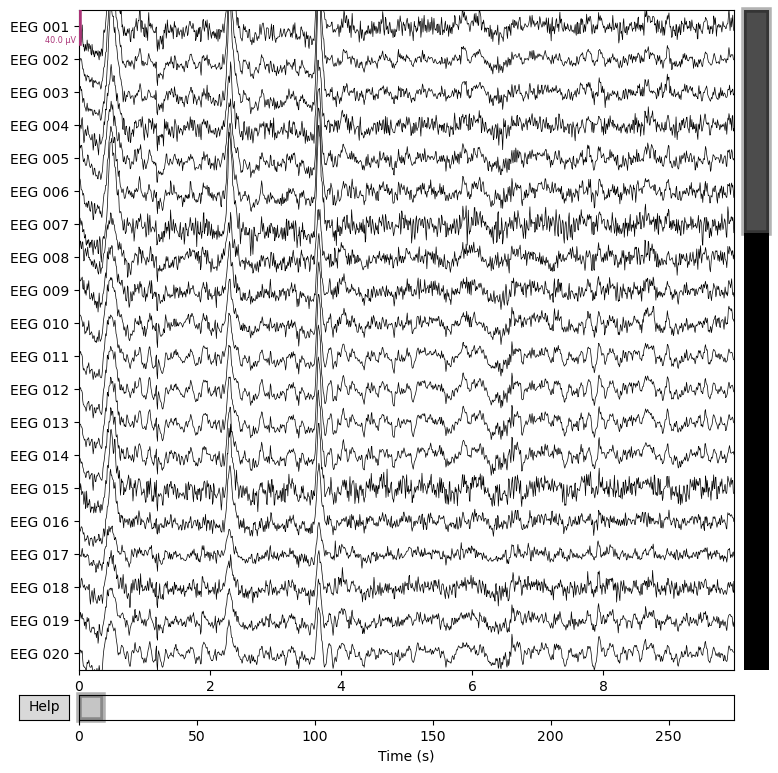

Opening raw data file C:\Users\Hangeulkim\mne_data\MNE-sample-data\MEG\sample\sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 3965 samples (6.602 s)

C:\Users\Hangeulkim\anaconda3\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).


C:\Users\Hangeulkim\anaconda3\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


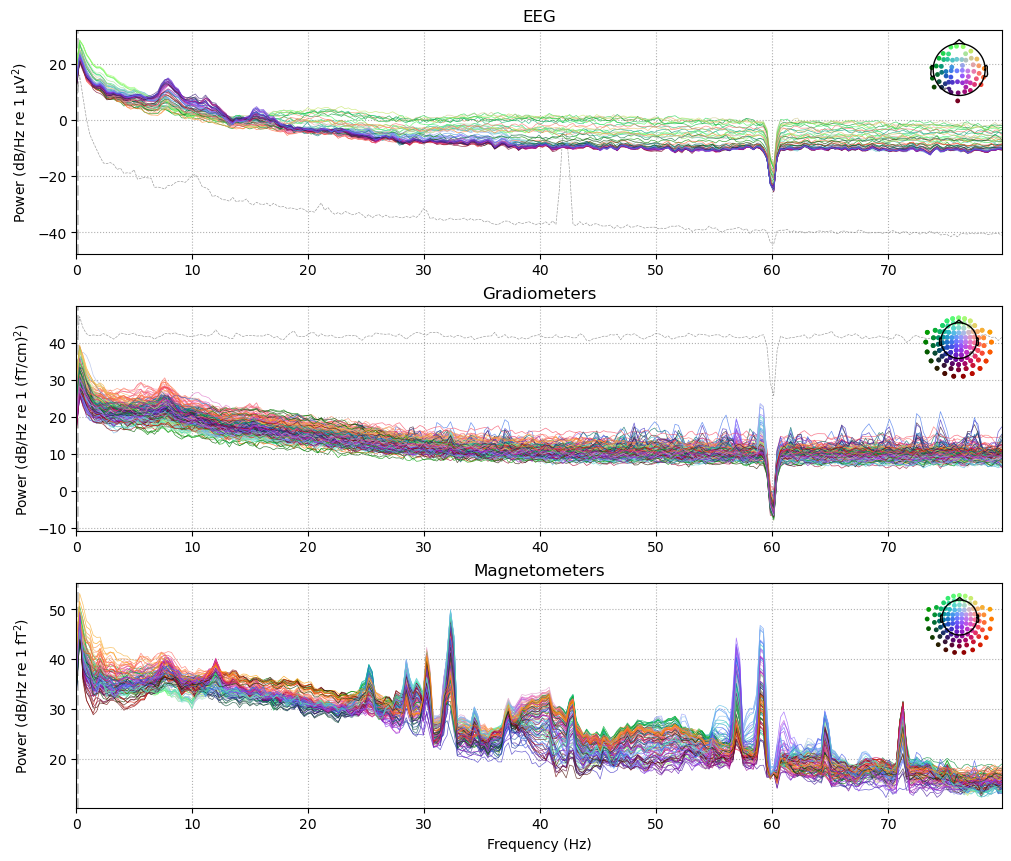

In [8]:
""" raw.info['sfreq'], raw.info['nchan']을 변수로 저장하고 출력.
EEG 채널만 골라서(raw.pick_types(eeg=True, meg=False)) 채널 수가 얼마나 줄었는지 확인.
notch filter 60Hz를 적용한 뒤 raw.plot_psd(fmax=80)로 전원 잡음 제거 효과 확인.
raw.copy()로 원본 보존한 후 필터 전/후를 같은 figure에 비교. """

sfreq, nchan = raw.info['sfreq'], raw.info['nchan']
print(sfreq, nchan)
raw.pick_types(eeg=True, meg=False)
raw.plot()

import numpy as np

raw2 = mne.io.read_raw_fif(raw_fname, preload=True)
times = raw2.times
noise = 5e-12 * np.sin(2 * np.pi * 60 * times)
raw2._data += noise[np.newaxis, :]
raw2.compute_psd(fmax=80).plot()
raw2.notch_filter(freqs=np.arange(60,raw2.info['sfreq']/2,60))
raw2.compute_psd(fmax=80).plot()